# Prédiction de la Gravité des Accidents - Decision Tree

Ce notebook implémente un pipeline complet de Machine Learning pour prédire la gravité des accidents corporels de la circulation en France à partir des données de 2024.

**Étapes:**
1. Chargement et exploration des données
2. Nettoyage et préparation
3. Séparation Train/Test
4. Modélisation avec Decision Tree
5. Évaluation (Accuracy, Precision, Recall, F1-Score, Matrice de Confusion)
6. Validation croisée

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Bibliothèques importées avec succès")

Bibliothèques importées avec succès


## 1. Chargement et Exploration des Données

In [ ]:
df = pd.read_csv('../data/raw/accidents_2024.csv', sep=';', encoding='latin-1')

print("Forme du dataset:", df.shape)
print("\n" + "="*60)
print("Informations sur le dataset:")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("Statistiques descriptives:")
print("="*60)
print(df.describe())

print("\n" + "="*60)
print("Distribution de la variable cible (Gravité):")
print("="*60)
print(df['Gravité (label)'].value_counts())
print("\nProportion:")
print(df['Gravité (label)'].value_counts(normalize=True))

print("\n" + "="*60)
print("Valeurs manquantes:")
print("="*60)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ Aucune valeur manquante détectée")
else:
    print(missing[missing > 0])

print("\n" + "="*60)
print("🔍 Premières lignes du dataset:")
print("="*60)
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/accidents_2024_cleaned.csv'

## 2. Nettoyage et Préparation des Données

In [ ]:
df_processed = df.copy()

print("Étape 1: Traitement des valeurs manquantes")
print("="*60)

missing_cols = df_processed.columns[df_processed.isnull().any()].tolist()
if missing_cols:
    print(f"Colonnes avec valeurs manquantes: {missing_cols}")
    # médiane pour numériques, mode pour catégoriels : limite la distorsion des distributions
    for col in missing_cols:
        if df_processed[col].dtype in ['float64', 'int64']:
            df_processed[col].fillna(df_processed[col].median(), inplace=True)
            print(f"  - {col}: rempli avec la médiane")
        else:
            df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)
            print(f"  - {col}: rempli avec le mode")
else:
    print("Aucune valeur manquante détectée")

print("\nÉtape 2: Identification des colonnes catégoriques")
print("="*60)

categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
print(f"Colonnes catégoriques identifiées: {categorical_cols}")

if 'Num_Acc' in df_processed.columns:
    df_processed = df_processed.drop(['Num_Acc'], axis=1)
    print("Colonne 'Num_Acc' supprimée (numéro d'accident)")

print("\nÉtape 3: Encodage des variables catégoriques")
print("="*60)

# LabelEncoder : le DT supporte les entiers directement, pas besoin d'exploser les colonnes comme en OHE
label_encoders = {}
for col in categorical_cols:
    if col != 'Num_Acc' and col in df_processed.columns:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        label_encoders[col] = le
        print(f"{col}: encodé avec {len(le.classes_)} classes")

print("\n" + "="*60)
print("Données préparées avec succès")
print("="*60)
print(f"\nForme finale du dataset: {df_processed.shape}")
print(f"\nTypes de données:\n{df_processed.dtypes}")
print(f"\nAperçu des données préparées:\n{df_processed.head()}")

Étape 1: Traitement des valeurs manquantes
Colonnes avec valeurs manquantes: ['Nombre de voies', 'Vitesse max autorisée']
  - Nombre de voies: rempli avec la médiane
  - Vitesse max autorisée: rempli avec la médiane

Étape 2: Identification des colonnes catégoriques
Colonnes catégoriques identifiées: ['Situation de l\x92accident']
Colonne 'Num_Acc' supprimée (numéro d'accident)

Étape 3: Encodage des variables catégoriques
Situation de laccident: encodé avec 7 classes

Données préparées avec succès

Forme finale du dataset: (41181, 13)

Types de données:
Département                  float64
Agglomération                  int64
Luminosité                     int64
Météo (conditions atmos.)      int64
Type de collision              int64
Catégorie de route             int64
Régime de circulation          int64
Nombre de voies              float64
État de la surface             int64
Infrastructure                 int64
Situation de laccident        int64
Vitesse max autorisée        fl

## 3. Séparation Train/Test et Préparation des Features

In [ ]:
print("Séparation des features et de la cible")
print("="*60)

X = df_processed.drop(['Gravité (label)'], axis=1)
y = df_processed['Gravité (label)']

print(f"Nombre de features: {X.shape[1]}")
print(f"Features: {X.columns.tolist()}")
print(f"\nNombre d'échantillons: {X.shape[0]}")
print(f"Distribution de la cible:\n{y.value_counts()}")

print("\n" + "="*60)
print("Train/Test Split (80/20)")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # stratify=y : conserve la proportion des classes rares dans chaque split
)

print(f"Ensemble d'entraînement (Train): {X_train.shape[0]} échantillons ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Ensemble de test (Test): {X_test.shape[0]} échantillons ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nDistribution dans l'ensemble Train:")
print(y_train.value_counts())

print(f"\nDistribution dans l'ensemble Test:")
print(y_test.value_counts())

Séparation des features et de la cible
Nombre de features: 12
Features: ['Département', 'Agglomération', 'Luminosité', 'Météo (conditions atmos.)', 'Type de collision', 'Catégorie de route', 'Régime de circulation', 'Nombre de voies', 'État de la surface', 'Infrastructure', 'Situation de l\x92accident', 'Vitesse max autorisée']

Nombre d'échantillons: 41181
Distribution de la cible:
Gravité (label)
1    24619
0    13572
2     2990
Name: count, dtype: int64

Train/Test Split (80/20)
Ensemble d'entraînement (Train): 32944 échantillons (80.0%)
Ensemble de test (Test): 8237 échantillons (20.0%)

Distribution dans l'ensemble Train:
Gravité (label)
1    19695
0    10857
2     2392
Name: count, dtype: int64

Distribution dans l'ensemble Test:
Gravité (label)
1    4924
0    2715
2     598
Name: count, dtype: int64


## 4. Modélisation avec Decision Tree Classifier

### Stratégie de régularisation pour éviter l'overfitting

Pour un Decision Tree, les paramètres clés pour prévenir l'overfitting sont:
- **max_depth**: Profondeur maximale de l'arbre (limite la complexité)
- **min_samples_split**: Nombre minimum d'échantillons pour diviser un nœud
- **min_samples_leaf**: Nombre minimum d'échantillons dans une feuille
- **max_features**: Nombre maximum de features à considérer

In [ ]:
print("Initialisation du Decision Tree Classifier")
print("="*60)

# max_depth + min_samples_* : contraintes de régularisation pour limiter l'overfitting
dt_classifier = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced'  # compense le déséquilibre Tué = 7%
)

print("Paramètres du modèle:")
print(f"  - max_depth: {dt_classifier.max_depth}")
print(f"  - min_samples_split: {dt_classifier.min_samples_split}")
print(f"  - min_samples_leaf: {dt_classifier.min_samples_leaf}")
print(f"  - max_features: {dt_classifier.max_features}")
print(f"  - class_weight: {dt_classifier.class_weight}")

print("\n" + "="*60)
print("Entraînement du modèle...")
print("="*60)

dt_classifier.fit(X_train, y_train)

print("Modèle entraîné avec succès!")
print(f"\nProfondeur réelle de l'arbre: {dt_classifier.get_depth()}")
print(f"Nombre de feuilles: {dt_classifier.get_n_leaves()}")
print(f"Nombre de features utilisées: {dt_classifier.n_features_in_}")

y_train_pred = dt_classifier.predict(X_train)
y_test_pred = dt_classifier.predict(X_test)

print("\nPrédictions effectuées sur train et test")

Initialisation du Decision Tree Classifier
Paramètres du modèle:
  - max_depth: 10
  - min_samples_split: 10
  - min_samples_leaf: 5
  - max_features: sqrt
  - class_weight: balanced

Entraînement du modèle...
Modèle entraîné avec succès!

Profondeur réelle de l'arbre: 10
Nombre de feuilles: 579
Nombre de features utilisées: 12

Prédictions effectuées sur train et test


## 5. Évaluation du Modèle

### Métriques de performance

- **Accuracy**: Proportion de prédictions correctes
- **Precision**: Proportion de prédictions positives correctes
- **Recall**: Proportion de vrais positifs détectés
- **F1-Score**: Moyenne harmonique de Precision et Recall

In [ ]:
def evaluate_model(y_true, y_pred, set_name=""):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"\nMétriques de Performance - {set_name}")
    print("="*60)
    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

train_metrics = evaluate_model(y_train, y_train_pred, "ENSEMBLE D'ENTRAÎNEMENT")

test_metrics = evaluate_model(y_test, y_test_pred, "ENSEMBLE DE TEST")

# écart train/test > 0.1 : signal d'overfitting
print("\n" + "="*60)
print("Analyse du Surapprentissage (Overfitting)")
print("="*60)

diff_accuracy = train_metrics['accuracy'] - test_metrics['accuracy']
print(f"Différence Accuracy (Train - Test): {diff_accuracy:.4f}")

if diff_accuracy > 0.1:
    print("Possible surapprentissage détecté (écart > 0.1)")
elif diff_accuracy < -0.05:
    print("Possible sous-apprentissage détecté")
else:
    print("Bon équilibre Train/Test")


Métriques de Performance - ENSEMBLE D'ENTRAÎNEMENT
  Accuracy:  0.4995 (49.95%)
  Precision: 0.6356
  Recall:    0.4995
  F1-Score:  0.5350

Métriques de Performance - ENSEMBLE DE TEST
  Accuracy:  0.4658 (46.58%)
  Precision: 0.5962
  Recall:    0.4658
  F1-Score:  0.5027

Analyse du Surapprentissage (Overfitting)
Différence Accuracy (Train - Test): 0.0336
Bon équilibre Train/Test



Rapport de Classification Détaillé - ENSEMBLE DE TEST
              precision    recall  f1-score   support

           0     0.3904    0.2210    0.2822      2715
           1     0.7662    0.5776    0.6586      4924
           2     0.1315    0.6572    0.2192       598

    accuracy                         0.4658      8237
   macro avg     0.4294    0.4853    0.3867      8237
weighted avg     0.5962    0.4658    0.5027      8237


Matrice de Confusion - ENSEMBLE DE TEST

[[ 600  779 1336]
 [ 821 2844 1259]
 [ 116   89  393]]



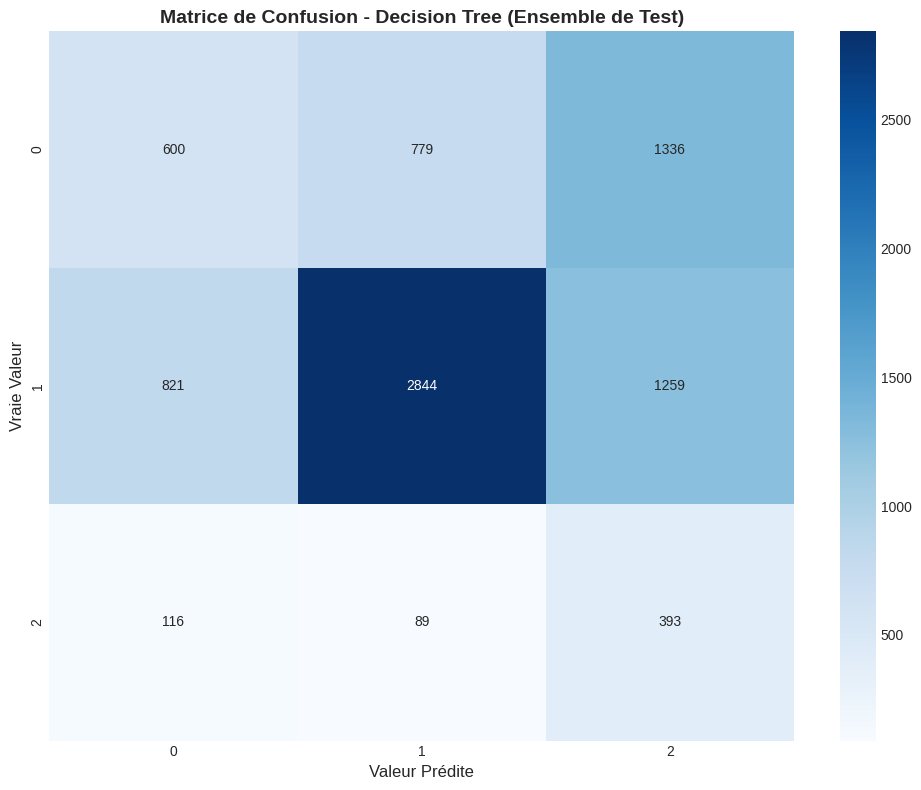

Matrice de confusion affichée


In [ ]:
print("\n" + "="*60)
print("Rapport de Classification Détaillé - ENSEMBLE DE TEST")
print("="*60)
print(classification_report(y_test, y_test_pred, digits=4))

print("\n" + "="*60)
print("Matrice de Confusion - ENSEMBLE DE TEST")
print("="*60)

cm = confusion_matrix(y_test, y_test_pred)
print(f"\n{cm}\n")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
ax.set_title('Matrice de Confusion - Decision Tree (Ensemble de Test)', fontsize=14, fontweight='bold')
ax.set_ylabel('Vraie Valeur', fontsize=12)
ax.set_xlabel('Valeur Prédite', fontsize=12)
plt.tight_layout()
plt.show()

print("Matrice de confusion affichée")

## 6. Validation Croisée (Cross-Validation)

La validation croisée divise les données en k plis (k-folds) pour obtenir une estimation plus robuste de la performance du modèle et réduire la variance.

Validation Croisée (5-Fold Cross-Validation)

Résultats de la Validation Croisée:
------------------------------------------------------------

ACCURACY:
  Scores par pli (Test):  ['0.4766', '0.4786', '0.4892', '0.4756', '0.4690']
  Moyenne Test:           0.4778 (+/- 0.0065)
  Moyenne Train:          0.5098

PRECISION_WEIGHTED:
  Scores par pli (Test):  ['0.6080', '0.6058', '0.5857', '0.5929', '0.5977']
  Moyenne Test:           0.5980 (+/- 0.0082)
  Moyenne Train:          0.6330

RECALL_WEIGHTED:
  Scores par pli (Test):  ['0.4766', '0.4786', '0.4892', '0.4756', '0.4690']
  Moyenne Test:           0.4778 (+/- 0.0065)
  Moyenne Train:          0.5098

F1_WEIGHTED:
  Scores par pli (Test):  ['0.5168', '0.5160', '0.5134', '0.5117', '0.5053']
  Moyenne Test:           0.5126 (+/- 0.0041)
  Moyenne Train:          0.5424

RÉSUMÉ DE LA VALIDATION CROISÉE
 Métrique  Moyenne (Test)  Écart-type
 Accuracy        0.477817    0.006535
Precision        0.598036    0.008216
   Recall        0.477

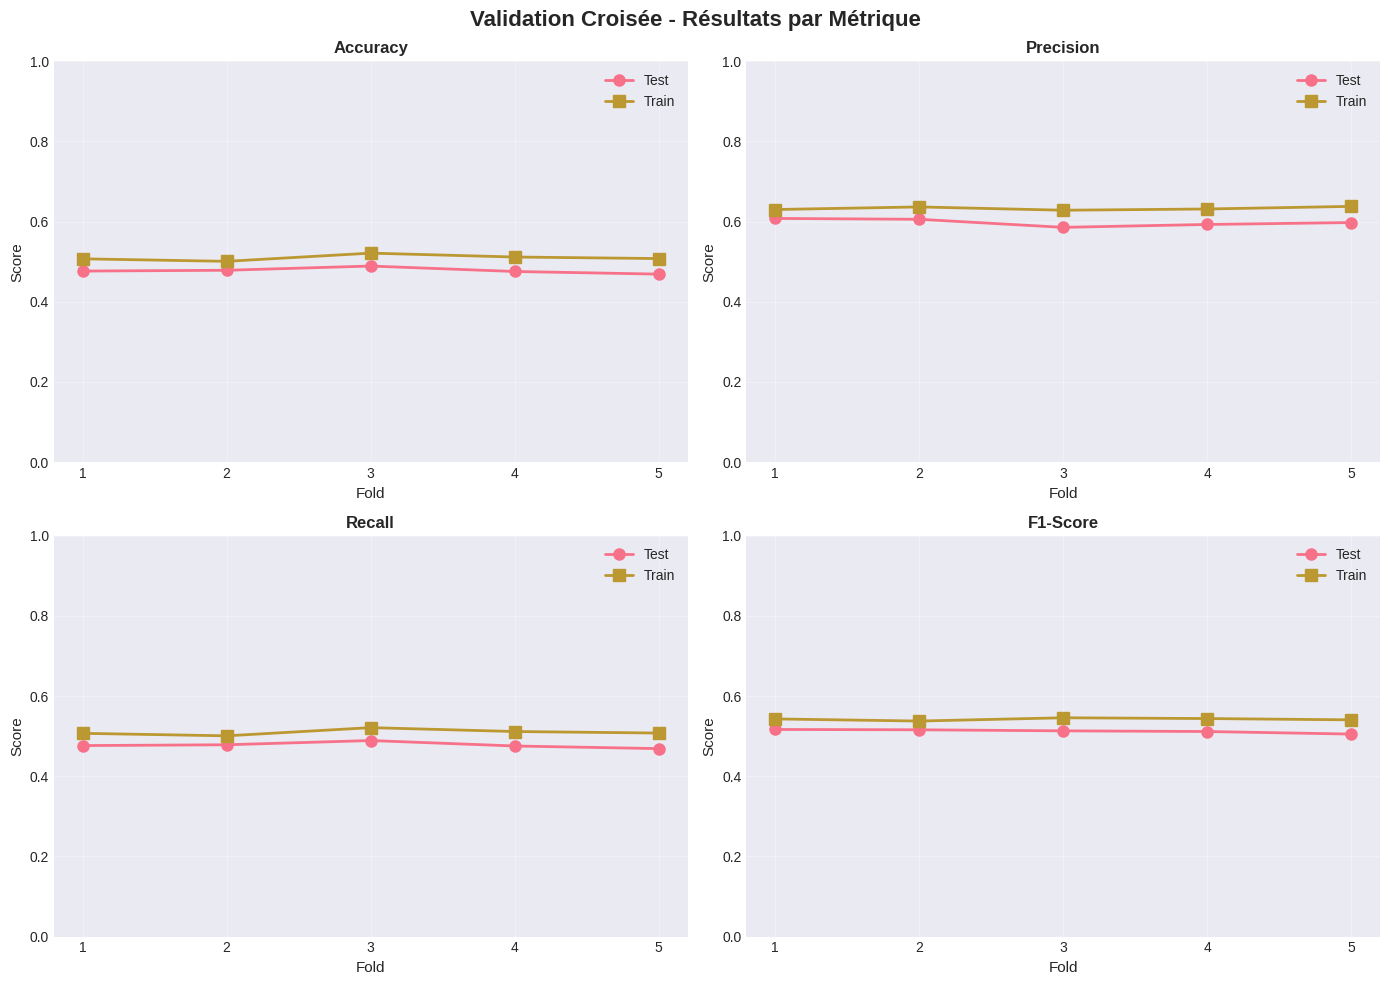


Validation croisée complétée avec succès


In [ ]:
print("Validation Croisée (5-Fold Cross-Validation)")
print("="*60)

scoring_metrics = {
    'accuracy': 'accuracy',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'f1_weighted': 'f1_weighted'
}

# CV sur l'ensemble complet : donne une estimation moins biaisée que le seul split 80/20
cv_results = cross_validate(
    dt_classifier, 
    X, y,
    cv=5,
    scoring=scoring_metrics,
    return_train_score=True
)

print("\nRésultats de la Validation Croisée:")
print("-"*60)

for metric in ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']:
    test_scores = cv_results[f'test_{metric}']
    train_scores = cv_results[f'train_{metric}']
    
    print(f"\n{metric.upper()}:")
    print(f"  Scores par pli (Test):  {[f'{s:.4f}' for s in test_scores]}")
    print(f"  Moyenne Test:           {test_scores.mean():.4f} (+/- {test_scores.std():.4f})")
    print(f"  Moyenne Train:          {train_scores.mean():.4f}")

print("\n" + "="*60)
print("RÉSUMÉ DE LA VALIDATION CROISÉE")
print("="*60)

summary_df = pd.DataFrame({
    'Métrique': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Moyenne (Test)': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_precision_weighted'].mean(),
        cv_results['test_recall_weighted'].mean(),
        cv_results['test_f1_weighted'].mean()
    ],
    'Écart-type': [
        cv_results['test_accuracy'].std(),
        cv_results['test_precision_weighted'].std(),
        cv_results['test_recall_weighted'].std(),
        cv_results['test_f1_weighted'].std()
    ]
})

print(summary_df.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Validation Croisée - Résultats par Métrique', fontsize=16, fontweight='bold')

metrics_to_plot = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (ax, metric, label) in enumerate(zip(axes.flatten(), metrics_to_plot, metric_labels)):
    test_scores = cv_results[f'test_{metric}']
    train_scores = cv_results[f'train_{metric}']
    
    folds = np.arange(1, 6)
    ax.plot(folds, test_scores, 'o-', label='Test', linewidth=2, markersize=8)
    ax.plot(folds, train_scores, 's-', label='Train', linewidth=2, markersize=8)
    ax.set_xlabel('Fold', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(f'{label}', fontsize=12, fontweight='bold')
    ax.set_xticks(folds)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\nValidation croisée complétée avec succès")

## 7. Importance des Features et Analyse du Modèle

Importance des Features

Top 10 des Features les Plus Importantes:
                Feature  Importance
          Agglomération    0.175694
            Département    0.168223
      Type de collision    0.118607
        Nombre de voies    0.107777
  Régime de circulation    0.092387
  Vitesse max autorisée    0.086506
     Catégorie de route    0.076646
Situation de laccident    0.041909
             Luminosité    0.040197
         Infrastructure    0.031452


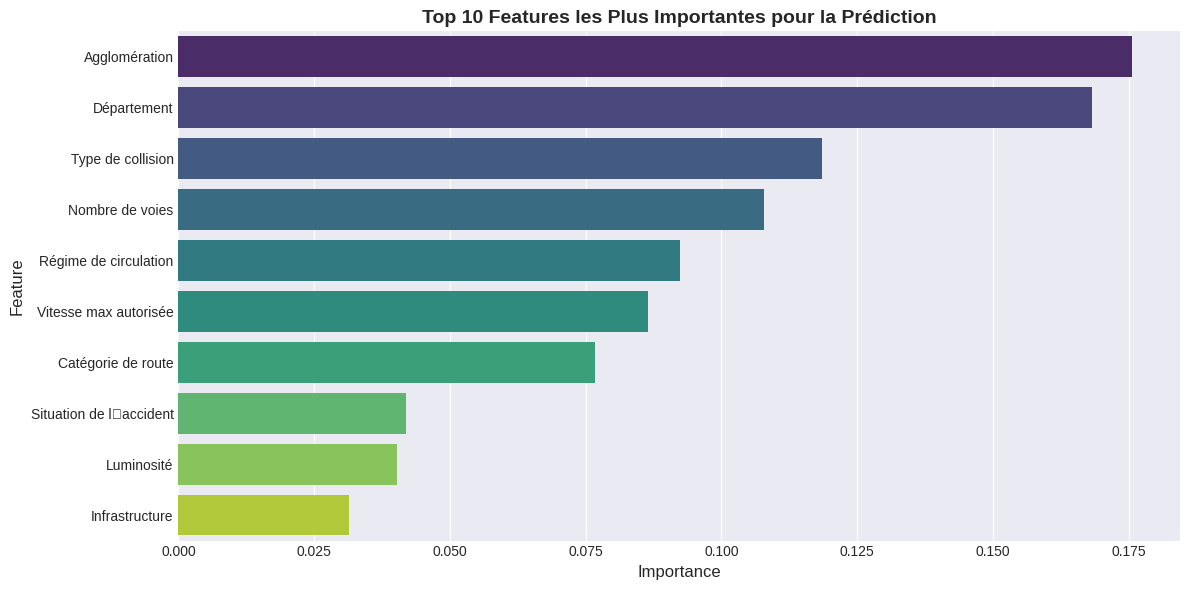


Importance des features calculée


In [ ]:
print("Importance des Features")
print("="*60)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 des Features les Plus Importantes:")
print(feature_importance.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature', ax=ax, palette='viridis')
ax.set_title('Top 10 Features les Plus Importantes pour la Prédiction', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\nImportance des features calculée")

Visualisation de l'Arbre de Décision


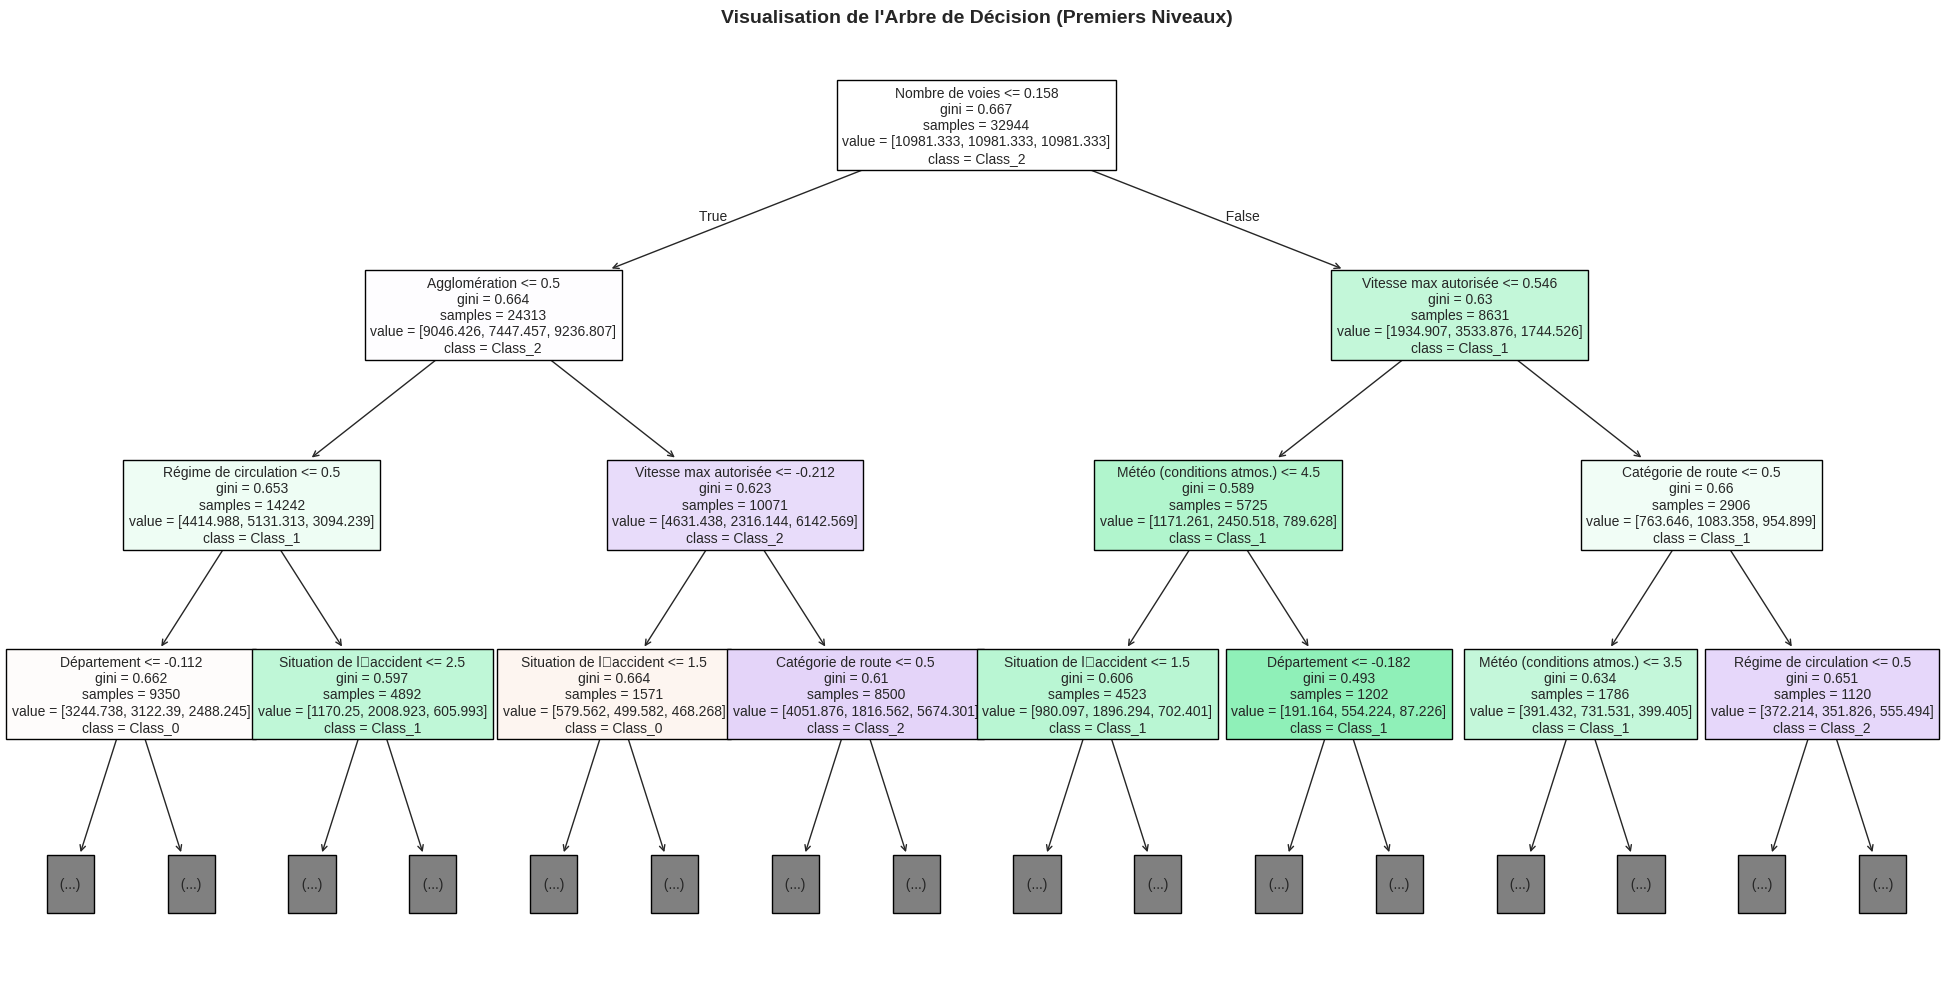

Arbre de décision visualisé (limité à 3 niveaux pour la clarté)


In [ ]:
print("Visualisation de l'Arbre de Décision")
print("="*60)

# Limiter à 5 niveaux pour une meilleure lisibilité
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_classifier,
    feature_names=X.columns,
    class_names=['Class_' + str(i) for i in np.unique(y)],
    filled=True,
    ax=ax,
    max_depth=3,  # au-delà, la visualisation devient illisible
    fontsize=10
)
ax.set_title('Visualisation de l\'Arbre de Décision (Premiers Niveaux)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Arbre de décision visualisé (limité à 3 niveaux pour la clarté)")

## 8. Résumé et Recommandations

In [ ]:
print("="*70)
print("RÉSUMÉ DU MODÈLE - PRÉDICTION DE LA GRAVITÉ DES ACCIDENTS")
print("="*70)

print("\nCONFIGURATION DU MODÈLE:")
print("-" * 70)
print(f"  - Algorithme: Decision Tree Classifier")
print(f"  - Max Depth: {dt_classifier.max_depth}")
print(f"  - Min Samples Split: {dt_classifier.min_samples_split}")
print(f"  - Min Samples Leaf: {dt_classifier.min_samples_leaf}")
print(f"  - Number of features: {dt_classifier.n_features_in_}")
print(f"  - Number of leaves: {dt_classifier.get_n_leaves()}")
print(f"  - Tree depth: {dt_classifier.get_depth()}")

print("\nPERFORMANCE SUR L'ENSEMBLE DE TEST:")
print("-" * 70)
print(f"  - Accuracy:  {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%)")
print(f"  - Precision: {test_metrics['precision']:.4f}")
print(f"  - Recall:    {test_metrics['recall']:.4f}")
print(f"  - F1-Score:  {test_metrics['f1']:.4f}")

print("\nVALIDATION CROISÉE (5-Fold):")
print("-" * 70)
print(f"  - Accuracy moyenne:  {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
print(f"  - Precision moyenne: {cv_results['test_precision_weighted'].mean():.4f} (+/- {cv_results['test_precision_weighted'].std():.4f})")
print(f"  - Recall moyen:      {cv_results['test_recall_weighted'].mean():.4f} (+/- {cv_results['test_recall_weighted'].std():.4f})")
print(f"  - F1-Score moyen:    {cv_results['test_f1_weighted'].mean():.4f} (+/- {cv_results['test_f1_weighted'].std():.4f})")

print("\nTOP 5 FEATURES LES PLUS IMPORTANTES:")
print("-" * 70)
for idx, row in feature_importance.head(5).iterrows():
    print(f"  {idx+1}. {row['Feature']:30s} - Importance: {row['Importance']:.4f}")

print("\nRECOMMANDATIONS:")
print("-" * 70)

cv_acc = cv_results['test_accuracy'].mean()
if cv_acc < 0.7:
    print("  Performance modérée - Considérez d'autres approches:")
    print("     • Essayer d'autres algoritmes (Random Forest, Gradient Boosting)")
    print("     • Améliorer l'ingénierie des features")
    print("     • Collecter plus de données")
elif cv_acc < 0.85:
    print(" Bonne performance - Le modèle est acceptable pour une déploiement initial")
    print("     • Considérer l'optimisation des hyperparamètres")
    print("     • Réévaluer avec d'autres méthodes ensemble (Random Forest, Voting)")
else:
    print(" Excellente performance - Le modèle est bien calibré")
    print("     • Prêt pour le déploiement")
    print("     • Monitorer la performance en production")

if diff_accuracy > 0.1:
    print("\n Signe possible de surapprentissage")
    print("     • Réduire max_depth")
    print("     • Augmenter min_samples_split ou min_samples_leaf")
elif diff_accuracy < -0.05:
    print("\n  Signe possible de sous-apprentissage")
    print("     • Augmenter la complexité du modèle (max_depth)")
    print("     • Vérifier la qualité des features")

print("\n" + "="*70)
print("Analyse complètement terminée!")
print("="*70)

RÉSUMÉ DU MODÈLE - PRÉDICTION DE LA GRAVITÉ DES ACCIDENTS

CONFIGURATION DU MODÈLE:
----------------------------------------------------------------------
  - Algorithme: Decision Tree Classifier
  - Max Depth: 10
  - Min Samples Split: 10
  - Min Samples Leaf: 5
  - Number of features: 12
  - Number of leaves: 579
  - Tree depth: 10

PERFORMANCE SUR L'ENSEMBLE DE TEST:
----------------------------------------------------------------------
  - Accuracy:  0.4658 (46.58%)
  - Precision: 0.5962
  - Recall:    0.4658
  - F1-Score:  0.5027

VALIDATION CROISÉE (5-Fold):
----------------------------------------------------------------------
  - Accuracy moyenne:  0.4778 (+/- 0.0065)
  - Precision moyenne: 0.5980 (+/- 0.0082)
  - Recall moyen:      0.4778 (+/- 0.0065)
  - F1-Score moyen:    0.5126 (+/- 0.0041)

TOP 5 FEATURES LES PLUS IMPORTANTES:
----------------------------------------------------------------------
  2. Agglomération                  - Importance: 0.1757
  1. Département    